# 🏀 NBA Shot Intelligence — Modeling

## Objetivo

El objetivo de este notebook es desarrollar un modelo de clasificación capaz de estimar la probabilidad de conversión de un lanzamiento NBA a partir de sus características.

La salida principal del modelo será una probabilidad esperada de acierto (`xFG%`), que posteriormente podrá utilizarse para evaluar la dificultad de los tiros y comparar el rendimiento real de los jugadores con el esperado.

In [68]:
#Librerias
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
import joblib
pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:.2f}".format

In [2]:
DATA_PATH = Path("../data/raw/NBA_2004_2025_Shots.csv")

In [3]:
dtype_config = {
    "SEASON_1": "category",
    "SEASON_2": "category",
    "TEAM_ID": "int32",
    "TEAM_NAME": "category",
    "PLAYER_ID": "int32",
    "PLAYER_NAME": "category",
    "GAME_ID": "int32",
    "HOME_TEAM": "category",
    "AWAY_TEAM": "category",
    "EVENT_TYPE": "category",
    "SHOT_MADE": "bool",
    "ACTION_TYPE": "category",
    "SHOT_TYPE": "category",
    "BASIC_ZONE": "category",
    "ZONE_NAME": "category",
    "ZONE_ABB": "category",
    "ZONE_RANGE": "category",
    "LOC_X": "float32",
    "LOC_Y": "float32",
    "SHOT_DISTANCE": "int16",
    "QUARTER": "int8",
    "MINS_LEFT": "int8",
    "SECS_LEFT": "int8",
}

df = pd.read_csv(
    DATA_PATH,
    dtype=dtype_config,
    parse_dates=["GAME_DATE"]
)

df = df.drop_duplicates().reset_index(drop=True)

df.shape

(4443512, 24)

## 1. Definición del problema

El problema se plantea como una tarea de clasificación binaria:

- `1`: el lanzamiento fue convertido.
- `0`: el lanzamiento fue fallado.

A diferencia de un modelo orientado únicamente a maximizar accuracy, el objetivo principal es obtener probabilidades de conversión bien estimadas.

Por este motivo, además de métricas tradicionales de clasificación, se prestará especial atención a métricas probabilísticas como ROC-AUC, Log Loss y Brier Score.

## 2. Selección inicial de variables

Para construir un modelo válido, solamente deben utilizarse variables disponibles en el momento del lanzamiento.

Se excluyen variables que identifican directamente el resultado del tiro o que no aportan información generalizable al problema.

In [4]:
TARGET = "SHOT_MADE"

In [5]:
excluded_features = [
    "SHOT_MADE",     # Target
    "EVENT_TYPE",    # Puede revelar directamente si el tiro fue Made Shot o Missed Shot
    "GAME_ID",       # Identificador
    "TEAM_ID",       # Identificador
    "PLAYER_ID",     # Identificador
    "GAME_DATE"      # No necesaria inicialmente
]

In [6]:
features = [
    "SHOT_DISTANCE",
    "LOC_X",
    "LOC_Y",
    "SHOT_TYPE",
    "ACTION_TYPE",
    "BASIC_ZONE",
    "ZONE_NAME",
    "ZONE_RANGE",
    "QUARTER",
    "MINS_LEFT",
    "SECS_LEFT"
]

In [7]:
X = df[features].copy()
y = df[TARGET].astype("int8")

In [8]:
model_df = df[
    df["SEASON_1"].astype(int) >= 2021
].copy()

In [9]:
model_df["SEASON_1"].value_counts().sort_index()

SEASON_1
2025    212442
2024    218687
2023    217207
2022    216718
2021    190971
2020         0
2019         0
2018         0
2017         0
2016         0
2015         0
2014         0
2013         0
2012         0
2011         0
2010         0
2009         0
2008         0
2007         0
2006         0
2005         0
2004         0
Name: count, dtype: int64

In [10]:
model_df.shape

(1056025, 24)

In [11]:
X = model_df[features].copy()
y = model_df[TARGET].astype("int8")

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

print(f"\nConversión train: {y_train.mean():.2%}")
print(f"Conversión test:  {y_test.mean():.2%}")

Train: (844820, 11)
Test:  (211205, 11)

Conversión train: 46.88%
Conversión test:  46.88%


## 3. Preprocesamiento

Las variables utilizadas por el modelo incluyen características numéricas y categóricas, por lo que requieren diferentes transformaciones antes del entrenamiento.

- Las variables numéricas serán imputadas mediante la mediana y estandarizadas.
- Las variables categóricas serán imputadas utilizando la categoría más frecuente y transformadas mediante One-Hot Encoding.

El preprocesamiento se implementará mediante `ColumnTransformer` y `Pipeline`, permitiendo aplicar las transformaciones de manera consistente durante el entrenamiento y la evaluación.

In [14]:
#Definimos variables numéricas y categóricas
numeric_features = [
    "SHOT_DISTANCE",
    "LOC_X",
    "LOC_Y",
    "QUARTER",
    "MINS_LEFT",
    "SECS_LEFT"
]

categorical_features = [
    "SHOT_TYPE",
    "ACTION_TYPE",
    "BASIC_ZONE",
    "ZONE_NAME",
    "ZONE_RANGE"
]

In [15]:
print(f"Variables numéricas: {len(numeric_features)}")
print(f"Variables categóricas: {len(categorical_features)}")
print(f"Total: {len(numeric_features) + len(categorical_features)}")

Variables numéricas: 6
Variables categóricas: 5
Total: 11


In [16]:
#Pipelines de transformación
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

## 4. Modelo baseline — Logistic Regression

Se utilizará una Regresión Logística como primer modelo de referencia.

Este modelo proporciona un baseline interpretable y, al tratarse de un clasificador probabilístico, permite obtener directamente una estimación de la probabilidad de conversión de cada lanzamiento.

Posteriormente, sus resultados serán comparados con modelos de mayor complejidad.

In [18]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [19]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['SHOT_DISTANCE','LOC_X','LOC_Y',...,'QUARTER','MINS_LEFT','SECS_LEFT']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

In [20]:
#Primera prediccion
y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [21]:
pd.DataFrame({
    "Real": y_test.values[:10],
    "Prediccion": y_pred[:10],
    "xFG": y_prob[:10]
}).round(3)

,Real,Prediccion,xFG
0,0,0,0.35
1,1,1,0.90
2,1,1,0.68
3,0,0,0.33
4,0,1,0.50
5,0,0,0.40
6,0,0,0.34
7,1,1,0.93
8,0,0,0.45
9,1,0,0.36


## 5. Evaluación del modelo baseline

El rendimiento de la Regresión Logística se evaluará utilizando tanto métricas de clasificación como métricas probabilísticas.

Debido a que el objetivo principal del proyecto es estimar la probabilidad de conversión de cada lanzamiento (`xFG%`), métricas como ROC-AUC, Log Loss y Brier Score tendrán especial relevancia.

Las métricas utilizadas serán:

- **Accuracy:** proporción total de predicciones correctas.
- **Precision:** proporción de tiros predichos como convertidos que realmente fueron convertidos.
- **Recall:** proporción de tiros convertidos correctamente identificados.
- **F1-Score:** balance entre Precision y Recall.
- **ROC-AUC:** capacidad del modelo para diferenciar tiros con mayor y menor probabilidad de conversión.
- **Log Loss:** penaliza probabilidades incorrectas, especialmente cuando el modelo está muy seguro.
- **Brier Score:** mide el error cuadrático entre la probabilidad estimada y el resultado real.

In [22]:
baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "Log Loss": log_loss(y_test, y_prob),
    "Brier Score": brier_score_loss(y_test, y_prob)
}

baseline_results = pd.DataFrame(
    baseline_metrics.items(),
    columns=["Métrica", "Valor"]
)

baseline_results["Valor"] = baseline_results["Valor"].round(4)

baseline_results

,Métrica,Valor
0,Accuracy,0.63
1,Precision,0.66
2,Recall,0.42
3,F1-Score,0.52
4,ROC-AUC,0.65
5,Log Loss,0.64
6,Brier Score,0.23


### Matriz de confusión

La matriz de confusión permite analizar cómo se distribuyen los aciertos y errores del modelo al clasificar los lanzamientos como convertidos o fallados.

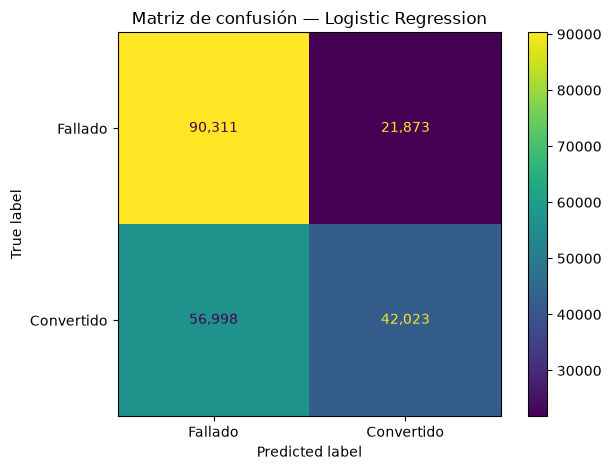

In [23]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Fallado", "Convertido"],
    values_format=","
)

plt.title("Matriz de confusión — Logistic Regression")
plt.tight_layout()
plt.show()

### Curva ROC

La curva ROC permite evaluar la capacidad del modelo para ordenar correctamente los lanzamientos según su probabilidad de conversión a través de diferentes umbrales de clasificación.

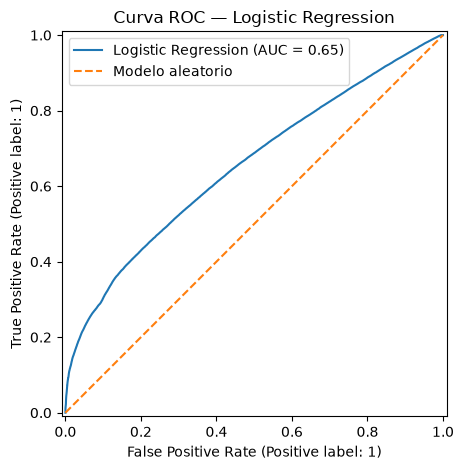

In [24]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Modelo aleatorio"
)

plt.title("Curva ROC — Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Calibración de probabilidades

Dado que el objetivo principal del modelo es estimar la probabilidad de conversión de cada lanzamiento (`xFG%`), es necesario evaluar no solo su capacidad de clasificación, sino también la calidad de las probabilidades generadas.

Un modelo perfectamente calibrado debería producir probabilidades consistentes con la frecuencia real de conversión. Por ejemplo, entre los lanzamientos con una probabilidad estimada cercana al 70 %, aproximadamente el 70 % deberían ser convertidos.

In [25]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="quantile"
)

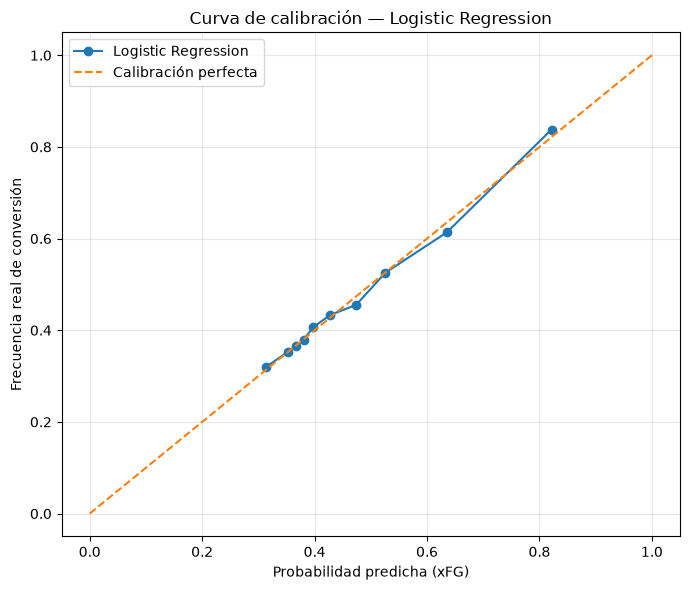

In [26]:
plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Calibración perfecta"
)

plt.xlabel("Probabilidad predicha (xFG)")
plt.ylabel("Frecuencia real de conversión")
plt.title("Curva de calibración — Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
calibration_results = pd.DataFrame({
    "xFG_promedio": prob_pred,
    "FG_real": prob_true
})

calibration_results["diferencia"] = (
    calibration_results["FG_real"]
    - calibration_results["xFG_promedio"]
)

calibration_results = calibration_results.round(4)

calibration_results

,xFG_promedio,FG_real,diferencia
0,0.31,0.32,0.01
1,0.35,0.35,0.00
2,0.37,0.36,-0.00
3,0.38,0.38,-0.00
4,0.40,0.41,0.01
5,0.43,0.43,0.01
6,0.47,0.46,-0.02
7,0.53,0.53,-0.00
8,0.64,0.61,-0.02
9,0.82,0.84,0.02


## 7. Conclusiones del modelo baseline

La Regresión Logística permitió establecer un primer modelo de referencia para estimar la probabilidad de conversión de los lanzamientos.

El modelo obtuvo un **ROC-AUC de 0,6543**, mostrando una capacidad moderada para diferenciar entre lanzamientos con mayor y menor probabilidad de conversión.

En términos probabilísticos, obtuvo un **Log Loss de 0,6409** y un **Brier Score de 0,2259**.

La curva de calibración muestra una correspondencia cercana entre las probabilidades estimadas (`xFG%`) y las frecuencias reales de conversión. En la mayoría de los grupos analizados, la diferencia entre ambas se mantiene por debajo de aproximadamente dos puntos porcentuales.

Estos resultados indican que, aunque existe margen para mejorar la capacidad predictiva del modelo, la Regresión Logística proporciona probabilidades razonablemente bien calibradas y constituye un baseline adecuado para comparar modelos de mayor complejidad.

## 8. XGBoost

In [28]:
tree_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

tree_categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", tree_numeric_pipeline, numeric_features),
        ("cat", tree_categorical_pipeline, categorical_features)
    ]
)

In [29]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [30]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['SHOT_DISTANCE','LOC_X','LOC_Y',...,'QUARTER','MINS_LEFT','SECS_LEFT']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``,

In [31]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [32]:
xgb_metrics = {
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1-Score": f1_score(y_test, xgb_pred),
    "ROC-AUC": roc_auc_score(y_test, xgb_prob),
    "Log Loss": log_loss(y_test, xgb_prob),
    "Brier Score": brier_score_loss(y_test, xgb_prob)
}

xgb_results = pd.DataFrame(
    xgb_metrics.items(),
    columns=["Métrica", "Valor"]
)

xgb_results["Valor"] = xgb_results["Valor"].round(4)

xgb_results

,Métrica,Valor
0,Accuracy,0.63
1,Precision,0.69
2,Recall,0.39
3,F1-Score,0.50
4,ROC-AUC,0.66
5,Log Loss,0.63
6,Brier Score,0.22


## 9. Comparación de modelos

El modelo XGBoost mejora el rendimiento del baseline de Regresión Logística en las principales métricas utilizadas para evaluar la estimación probabilística.

XGBoost alcanza un ROC-AUC de **0,6635**, frente a **0,6543** de la Regresión Logística. También reduce el Log Loss de **0,6409 a 0,6344** y el Brier Score de **0,2259 a 0,2231**.

Aunque la Regresión Logística obtiene mejores resultados en Recall y F1-Score utilizando un umbral de clasificación de 0,5, estas métricas tienen menor relevancia para el objetivo principal del proyecto, que consiste en estimar probabilidades de conversión (`xFG%`) y no únicamente clasificar los tiros como convertidos o fallados.

Por lo tanto, XGBoost presenta inicialmente un mejor rendimiento como modelo de estimación de la calidad esperada de los lanzamientos.

In [33]:
model_comparison = pd.DataFrame({
    "Logistic Regression": baseline_metrics,
    "XGBoost": xgb_metrics
}).T

model_comparison.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Log Loss,Brier Score
Logistic Regression,0.63,0.66,0.42,0.52,0.65,0.64,0.23
XGBoost,0.63,0.69,0.39,0.50,0.66,0.63,0.22


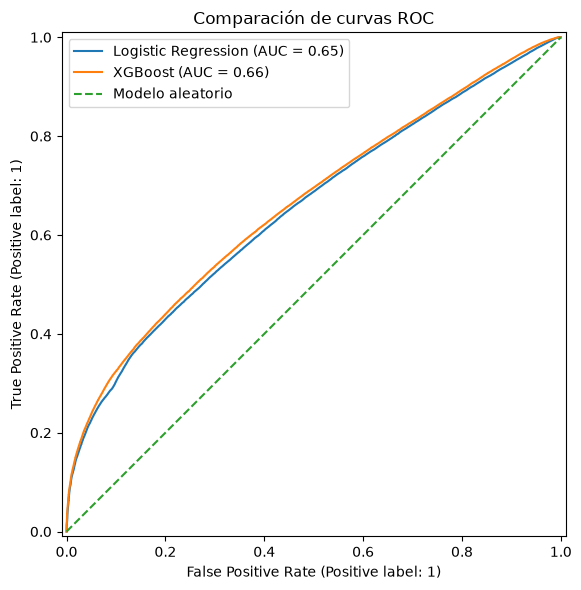

In [34]:
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    xgb_prob,
    name="XGBoost",
    ax=ax
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Modelo aleatorio"
)

ax.set_title("Comparación de curvas ROC")
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
xgb_prob_true, xgb_prob_pred = calibration_curve(
    y_test,
    xgb_prob,
    n_bins=10,
    strategy="quantile"
)

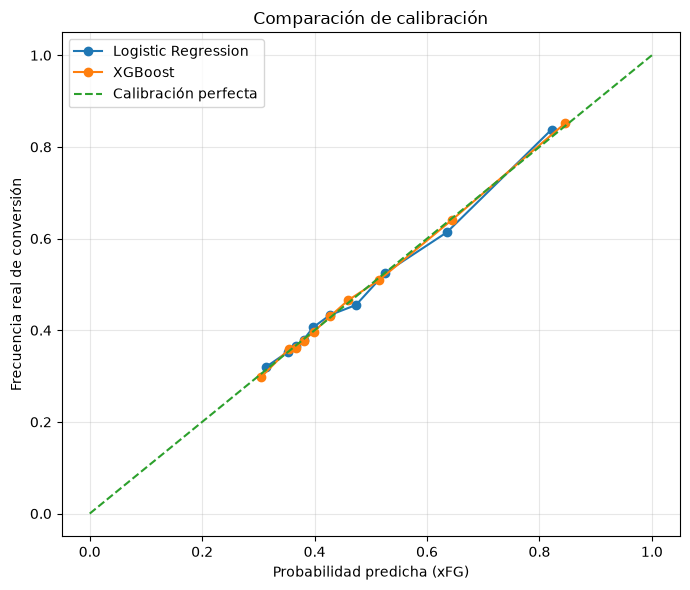

In [74]:
plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    xgb_prob_pred,
    xgb_prob_true,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Calibración perfecta"
)

plt.xlabel("Probabilidad predicha (xFG)")
plt.ylabel("Frecuencia real de conversión")
plt.title("Comparación de calibración")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../reports/figures/model_calibration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
xgb_calibration = pd.DataFrame({
    "xFG_promedio": xgb_prob_pred,
    "FG_real": xgb_prob_true
})

xgb_calibration["diferencia"] = (
    xgb_calibration["FG_real"]
    - xgb_calibration["xFG_promedio"]
)

xgb_calibration.round(4)

,xFG_promedio,FG_real,diferencia
0,0.30,0.30,-0.01
1,0.35,0.36,0.00
2,0.37,0.36,-0.01
3,0.38,0.38,-0.00
4,0.40,0.40,-0.00
5,0.43,0.43,0.00
6,0.46,0.47,0.01
7,0.51,0.51,-0.01
8,0.64,0.64,-0.00
9,0.85,0.85,0.01


## 10. Selección del modelo

La comparación entre los modelos muestra que XGBoost presenta el mejor rendimiento general para el objetivo del proyecto.

Respecto a la Regresión Logística, XGBoost mejora las principales métricas probabilísticas:

- ROC-AUC: **0,6543 → 0,6635**
- Log Loss: **0,6409 → 0,6344**
- Brier Score: **0,2259 → 0,2231**

Además, la curva de calibración muestra una correspondencia muy cercana entre las probabilidades estimadas y las frecuencias reales de conversión.

En los diez grupos de probabilidad analizados, las diferencias entre el xFG promedio y el FG% observado se mantienen por debajo de aproximadamente un punto porcentual.

Por lo tanto, XGBoost es seleccionado como modelo principal para la estimación del Expected Field Goal Percentage (`xFG%`).

## 11. Validación temporal

Además de la partición aleatoria utilizada durante el desarrollo, se realizará una evaluación temporal del modelo.

El modelo será entrenado utilizando lanzamientos correspondientes a las temporadas 2021-2024 y posteriormente evaluado sobre la temporada 2025.

Esta estrategia permite analizar la capacidad del modelo para generalizar hacia datos futuros que no estuvieron disponibles durante el entrenamiento.

In [38]:
train_mask = model_df["SEASON_1"].astype(int) < 2025
test_mask = model_df["SEASON_1"].astype(int) == 2025

X_train_time = model_df.loc[
    train_mask,
    features
].copy()

y_train_time = model_df.loc[
    train_mask,
    TARGET
].astype("int8")

X_test_time = model_df.loc[
    test_mask,
    features
].copy()

y_test_time = model_df.loc[
    test_mask,
    TARGET
].astype("int8")

In [39]:
print(f"Train temporal: {X_train_time.shape}")
print(f"Test temporal:  {X_test_time.shape}")

print(
    f"\nConversión train: "
    f"{y_train_time.mean():.2%}"
)

print(
    f"Conversión test:  "
    f"{y_test_time.mean():.2%}"
)

Train temporal: (843583, 11)
Test temporal:  (212442, 11)

Conversión train: 46.94%
Conversión test:  46.67%


In [40]:
xgb_temporal = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [41]:
xgb_temporal.fit(
    X_train_time,
    y_train_time
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['SHOT_DISTANCE','LOC_X','LOC_Y',...,'QUARTER','MINS_LEFT','SECS_LEFT']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``,

In [42]:
temporal_pred = xgb_temporal.predict(
    X_test_time
)

temporal_prob = xgb_temporal.predict_proba(
    X_test_time
)[:, 1]

In [43]:
temporal_metrics = {
    "Accuracy": accuracy_score(
        y_test_time,
        temporal_pred
    ),
    "Precision": precision_score(
        y_test_time,
        temporal_pred
    ),
    "Recall": recall_score(
        y_test_time,
        temporal_pred
    ),
    "F1-Score": f1_score(
        y_test_time,
        temporal_pred
    ),
    "ROC-AUC": roc_auc_score(
        y_test_time,
        temporal_prob
    ),
    "Log Loss": log_loss(
        y_test_time,
        temporal_prob
    ),
    "Brier Score": brier_score_loss(
        y_test_time,
        temporal_prob
    )
}

temporal_results = pd.DataFrame(
    temporal_metrics.items(),
    columns=["Métrica", "Valor"]
)

temporal_results["Valor"] = (
    temporal_results["Valor"].round(4)
)

temporal_results

,Métrica,Valor
0,Accuracy,0.63
1,Precision,0.69
2,Recall,0.38
3,F1-Score,0.49
4,ROC-AUC,0.66
5,Log Loss,0.64
6,Brier Score,0.22


## 12. Resultados de la validación temporal

Para evaluar la capacidad de generalización del modelo, XGBoost fue entrenado utilizando las temporadas 2021-2024 y evaluado exclusivamente sobre la temporada 2025.

El modelo mantuvo un rendimiento muy similar al obtenido mediante la partición aleatoria:

| Métrica | Random Split | Temporal Split |
|---|---:|---:|
| Accuracy | 0,6324 | 0,6321 |
| ROC-AUC | 0,6635 | 0,6602 |
| Log Loss | 0,6344 | 0,6360 |
| Brier Score | 0,2231 | 0,2237 |

La reducción del ROC-AUC es de apenas 0,0033, mientras que las métricas probabilísticas presentan variaciones igualmente pequeñas.

Estos resultados sugieren que el modelo mantiene una capacidad de generalización estable al ser aplicado sobre una temporada futura que no estuvo presente durante el entrenamiento.

Por este motivo, la validación temporal se considera una estimación más realista del rendimiento esperado del modelo sobre nuevos datos.

## 13. Optimización de hiperparámetros

A partir del modelo base de XGBoost, se evaluarán diferentes configuraciones de complejidad y tasa de aprendizaje.

La comparación se realizará utilizando la validación temporal, manteniendo la temporada 2025 completamente separada del entrenamiento.

La selección del modelo se basará principalmente en ROC-AUC, Log Loss y Brier Score.

In [44]:
xgb_configs = {
    "Baseline": {
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.05
    },

    "Modelo_A": {
        "n_estimators": 400,
        "max_depth": 4,
        "learning_rate": 0.05
    },

    "Modelo_B": {
        "n_estimators": 500,
        "max_depth": 5,
        "learning_rate": 0.03
    },

    "Modelo_C": {
        "n_estimators": 250,
        "max_depth": 8,
        "learning_rate": 0.05
    }
}

In [45]:
tuning_results = []

for name, params in xgb_configs.items():

    model = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "classifier",
                XGBClassifier(
                    **params,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

    model.fit(
        X_train_time,
        y_train_time
    )

    prob = model.predict_proba(
        X_test_time
    )[:, 1]

    tuning_results.append({
        "Modelo": name,
        "ROC-AUC": roc_auc_score(
            y_test_time,
            prob
        ),
        "Log Loss": log_loss(
            y_test_time,
            prob
        ),
        "Brier Score": brier_score_loss(
            y_test_time,
            prob
        )
    })

In [46]:
tuning_results = pd.DataFrame(
    tuning_results
)

tuning_results[
    ["ROC-AUC", "Log Loss", "Brier Score"]
] = tuning_results[
    ["ROC-AUC", "Log Loss", "Brier Score"]
].round(4)

tuning_results.sort_values(
    "ROC-AUC",
    ascending=False
)

,Modelo,ROC-AUC,Log Loss,Brier Score
0,Baseline,0.66,0.64,0.22
2,Modelo_B,0.66,0.64,0.22
3,Modelo_C,0.66,0.64,0.22
1,Modelo_A,0.66,0.64,0.22


## 14. Resultados de la optimización

Se evaluaron diferentes configuraciones de XGBoost modificando la profundidad de los árboles, la tasa de aprendizaje y la cantidad de estimadores.

Las configuraciones alternativas presentaron resultados muy similares al modelo baseline. Sin embargo, ninguna logró mejorar simultáneamente sus principales métricas probabilísticas.

El modelo baseline obtuvo:

- **ROC-AUC:** 0,6602
- **Log Loss:** 0,6360
- **Brier Score:** 0,2237

Por lo tanto, se mantiene la configuración original de XGBoost como modelo final. Los resultados sugieren que aumentar la complejidad del modelo no produce mejoras relevantes en su capacidad de generalización sobre la temporada 2025.

## 15. Expected Field Goal Percentage por jugador

A partir de las probabilidades generadas por el modelo sobre la temporada 2025, se calculará el Expected Field Goal Percentage (`xFG%`) de cada jugador.

La diferencia entre el porcentaje real de conversión y el esperado permitirá construir una métrica de Shot Making:

**Shot Making = FG% real − xFG%**

Un valor positivo indica que el jugador convirtió sus lanzamientos por encima de lo esperado según las características de los tiros realizados, mientras que un valor negativo indica un rendimiento inferior al esperado.

In [47]:
shots_2025 = model_df.loc[
    test_mask
].copy()

shots_2025["xFG"] = temporal_prob

In [48]:
shots_2025[
    [
        "PLAYER_NAME",
        "SHOT_MADE",
        "SHOT_DISTANCE",
        "BASIC_ZONE",
        "xFG"
    ]
].head(10)

,PLAYER_NAME,SHOT_MADE,SHOT_DISTANCE,BASIC_ZONE,xFG
0,Zaccharie Risacher,False,26,Above the Break 3,0.36
1,Jalen Johnson,False,13,Mid-Range,0.46
2,Jalen Johnson,True,25,Above the Break 3,0.37
3,Keaton Wallace,False,25,Above the Break 3,0.37
4,Clint Capela,True,2,Restricted Area,0.60
5,Zaccharie Risacher,True,1,Restricted Area,0.77
6,Zaccharie Risacher,False,12,In The Paint (Non-RA),0.47
7,Zaccharie Risacher,False,1,Restricted Area,0.69
8,Zaccharie Risacher,False,1,Restricted Area,0.23
9,Zaccharie Risacher,False,0,Restricted Area,0.54


In [49]:
#Agregamos por jugador
player_xfg = (
    shots_2025
    .groupby("PLAYER_NAME", observed=True)
    .agg(
        attempts=("SHOT_MADE", "size"),
        made=("SHOT_MADE", "sum"),
        fg_pct=("SHOT_MADE", "mean"),
        xfg_pct=("xFG", "mean")
    )
    .reset_index()
)

In [50]:
player_xfg["shot_making"] = (
    player_xfg["fg_pct"]
    - player_xfg["xfg_pct"]
)

In [51]:
percentage_cols = [
    "fg_pct",
    "xfg_pct",
    "shot_making"
]

player_xfg[percentage_cols] = (
    player_xfg[percentage_cols] * 100
)

player_xfg[percentage_cols] = (
    player_xfg[percentage_cols].round(2)
)

In [52]:
player_xfg.head()

,PLAYER_NAME,attempts,made,fg_pct,xfg_pct,shot_making
0,Adama Sanogo,7,4,57.14,63.34,-6.19
1,Al Horford,461,195,42.30,41.84,0.46
2,Ayo Dosunmu,449,221,49.22,50.64,-1.42
3,Baylor Scheierman,110,39,35.45,39.58,-4.12
4,Ben Simmons,170,93,54.71,55.91,-1.20


In [53]:
MIN_ATTEMPTS_2025 = 300
qualified_xfg = player_xfg[
    player_xfg["attempts"] >= MIN_ATTEMPTS_2025
].copy()

In [54]:
print(
    f"Jugadores con al menos {MIN_ATTEMPTS_2025} tiros: "
    f"{len(qualified_xfg)}"
)

Jugadores con al menos 300 tiros: 267


In [55]:
#Primer ranking
top_shot_makers = (
    qualified_xfg
    .sort_values(
        "shot_making",
        ascending=False
    )
    .head(15)
)

top_shot_makers[
    [
        "PLAYER_NAME",
        "attempts",
        "fg_pct",
        "xfg_pct",
        "shot_making"
    ]
]

,PLAYER_NAME,attempts,fg_pct,xfg_pct,shot_making
165,Nikola Jokić,1364,57.62,47.06,10.57
413,Kevin Durant,1124,52.67,43.81,8.86
183,Ty Jerome,618,51.62,42.76,8.86
83,Payton Pritchard,866,47.23,39.37,7.86
86,Seth Curry,343,47.81,40.65,7.16
246,Luke Kennard,431,47.80,41.26,6.53
79,Nikola Vučević,1038,52.99,46.45,6.53
496,Keon Ellis,464,48.92,42.40,6.52
199,Brandon Clarke,380,62.11,55.61,6.50
85,Sam Hauser,474,45.15,39.15,6.00


In [56]:
bottom_shot_makers = (
    qualified_xfg
    .sort_values(
        "shot_making",
        ascending=True
    )
    .head(15)
)

bottom_shot_makers[
    [
        "PLAYER_NAME",
        "attempts",
        "fg_pct",
        "xfg_pct",
        "shot_making"
    ]
]

,PLAYER_NAME,attempts,fg_pct,xfg_pct,shot_making
490,Jonathan Mogbo,356,43.82,57.97,-14.15
91,Tidjane Salaün,345,33.04,42.84,-9.80
438,Precious Achiuwa,327,50.15,59.55,-9.39
405,Jonathan Isaac,324,41.36,50.56,-9.20
359,Yves Missi,491,54.79,63.95,-9.17
11,Clint Capela,390,55.90,65.03,-9.13
56,KJ Simpson,301,34.55,43.48,-8.93
440,Ricky Council IV,463,38.23,46.12,-7.90
525,Bilal Coulibaly,624,42.15,49.52,-7.38
80,Noah Clowney,372,35.75,43.09,-7.33


## 16. Interpretación del Shot Making

El análisis del Shot Making permite comparar el porcentaje real de conversión de cada jugador con la dificultad estimada de sus lanzamientos.

Entre los jugadores con al menos 300 intentos en la temporada 2025, Nikola Jokić presenta la mayor diferencia positiva, con un FG% de 57,62 % frente a un xFG% de 47,06 %, equivalente a un Shot Making de +10,57 puntos porcentuales.

También destacan jugadores como Kevin Durant (+8,86), Ty Jerome (+8,86), Payton Pritchard (+7,86) y Seth Curry (+7,16).

En el extremo opuesto aparecen jugadores cuyo porcentaje real de conversión se encuentra considerablemente por debajo del esperado según las características de sus lanzamientos.

Es importante señalar que el xFG representa una estimación basada exclusivamente en las variables disponibles en el dataset. Factores como la distancia del defensor, nivel de contestación, movimiento previo al lanzamiento o contexto táctico no se encuentran disponibles, por lo que el Shot Making debe interpretarse como rendimiento respecto al valor esperado por el modelo y no como una medición absoluta de habilidad individual.

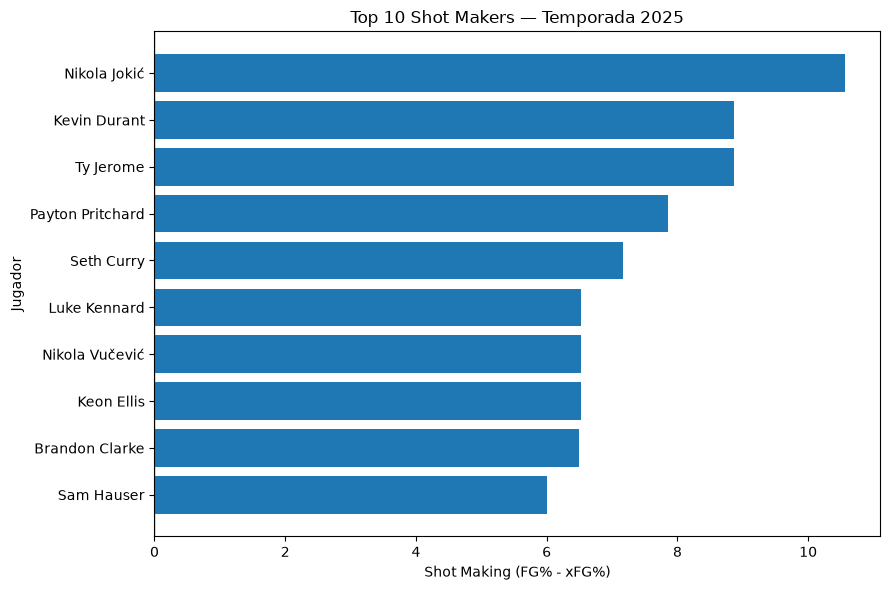

In [57]:
top10_shot_makers = (
    qualified_xfg
    .nlargest(10, "shot_making")
    .sort_values("shot_making")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top10_shot_makers["PLAYER_NAME"],
    top10_shot_makers["shot_making"]
)

plt.xlabel("Shot Making (FG% - xFG%)")
plt.ylabel("Jugador")
plt.title("Top 10 Shot Makers — Temporada 2025")
plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()

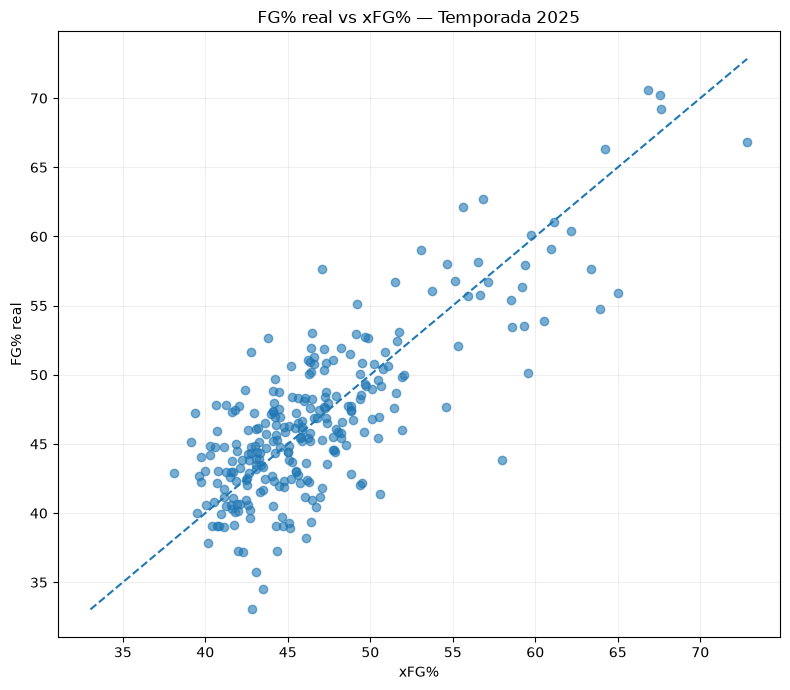

In [72]:
plt.figure(figsize=(8, 7))

plt.scatter(
    qualified_xfg["xfg_pct"],
    qualified_xfg["fg_pct"],
    alpha=0.6
)

min_value = min(
    qualified_xfg["xfg_pct"].min(),
    qualified_xfg["fg_pct"].min()
)

max_value = max(
    qualified_xfg["xfg_pct"].max(),
    qualified_xfg["fg_pct"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("xFG%")
plt.ylabel("FG% real")
plt.title("FG% real vs xFG% — Temporada 2025")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [59]:
players_to_label = pd.concat([
    qualified_xfg.nlargest(5, "shot_making"),
    qualified_xfg.nsmallest(5, "shot_making")
])

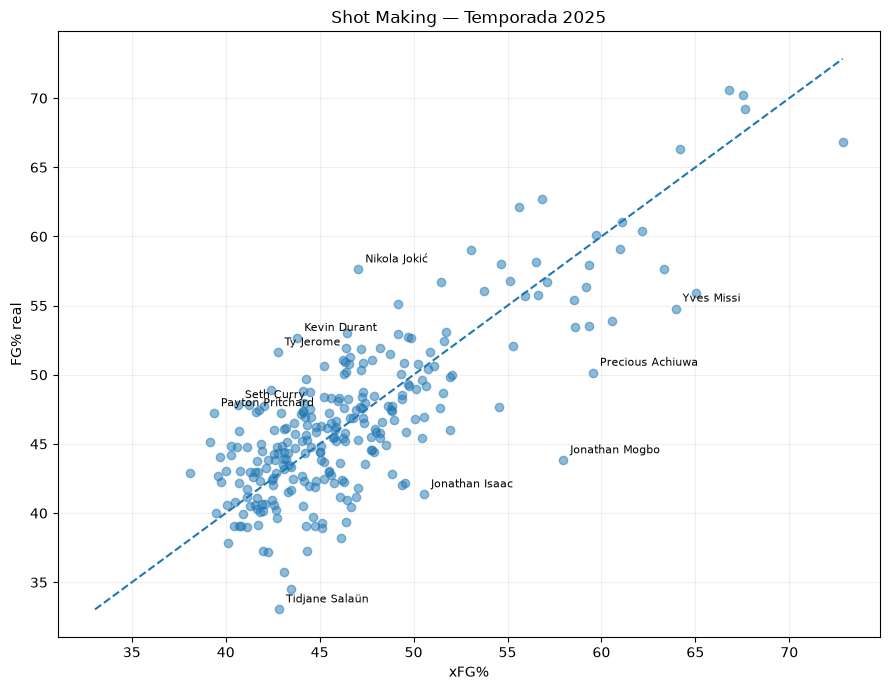

In [73]:
plt.figure(figsize=(9, 7))

plt.scatter(
    qualified_xfg["xfg_pct"],
    qualified_xfg["fg_pct"],
    alpha=0.5
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

for _, player in players_to_label.iterrows():
    plt.annotate(
        player["PLAYER_NAME"],
        (player["xfg_pct"], player["fg_pct"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("xFG%")
plt.ylabel("FG% real")
plt.title("Shot Making — Temporada 2025")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "../reports/figures/shot_making_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 17. Importancia de variables

Para comprender qué características tienen mayor influencia en las predicciones del modelo XGBoost, se analizará la importancia de las variables utilizadas para estimar el xFG%.

Debido al uso de One-Hot Encoding, las variables categóricas generan múltiples características individuales. Por este motivo, primero se analizarán las características transformadas y posteriormente se agruparán para obtener una interpretación a nivel de variable original.

In [61]:
final_preprocessor = xgb_temporal.named_steps["preprocessor"]
final_classifier = xgb_temporal.named_steps["classifier"]

feature_names = final_preprocessor.get_feature_names_out()

len(feature_names)

74

In [62]:
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": final_classifier.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(20)

,feature,importance
0,cat__BASIC_ZONE_Restricted Area,0.24
1,cat__ZONE_RANGE_Less Than 8 ft.,0.10
2,num__SHOT_DISTANCE,0.06
3,cat__ACTION_TYPE_Tip Layup Shot,0.06
4,cat__SHOT_TYPE_3PT Field Goal,0.06
5,cat__ACTION_TYPE_Driving Layup Shot,0.05
6,cat__ACTION_TYPE_Cutting Dunk Shot,0.05
7,cat__ACTION_TYPE_Running Dunk Shot,0.04
8,cat__SHOT_TYPE_2PT Field Goal,0.04
9,cat__ACTION_TYPE_Alley Oop Dunk Shot,0.03


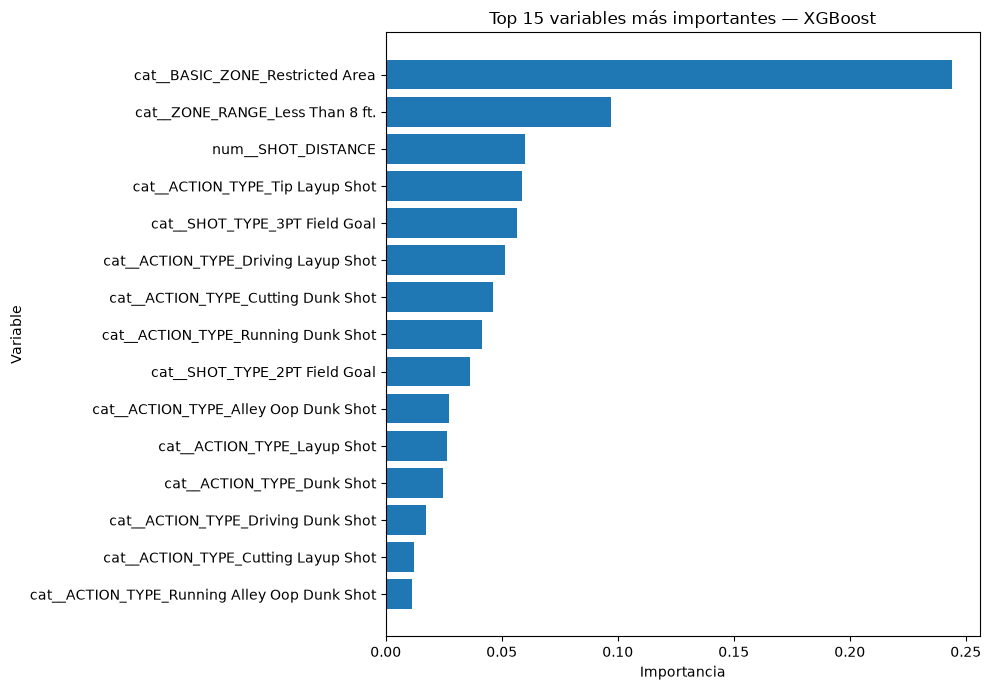

In [63]:
top_features = feature_importance.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 15 variables más importantes — XGBoost")
plt.tight_layout()
plt.show()

In [64]:
def get_original_feature(feature_name):

    if feature_name.startswith("num__"):
        return feature_name.replace("num__", "")

    if feature_name.startswith("cat__"):
        clean_name = feature_name.replace("cat__", "")

        for feature in categorical_features:
            if clean_name.startswith(feature + "_"):
                return feature

    return feature_name

In [65]:
feature_importance["original_feature"] = (
    feature_importance["feature"]
    .apply(get_original_feature)
)

In [66]:
grouped_importance = (
    feature_importance
    .groupby("original_feature", as_index=False)
    ["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

grouped_importance["importance"] = (
    grouped_importance["importance"].round(4)
)

grouped_importance

,original_feature,importance
0,ACTION_TYPE,0.46
1,BASIC_ZONE,0.27
10,ZONE_RANGE,0.10
8,SHOT_TYPE,0.09
7,SHOT_DISTANCE,0.06
9,ZONE_NAME,0.01
3,LOC_Y,0.00
2,LOC_X,0.00
4,MINS_LEFT,0.00
6,SECS_LEFT,0.00


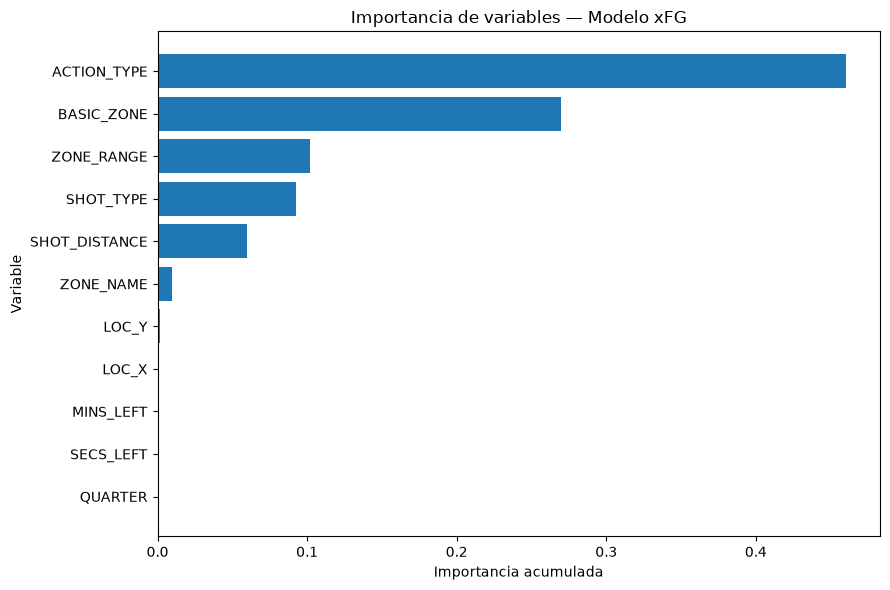

In [75]:
plot_importance = grouped_importance.sort_values(
    "importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_importance["original_feature"],
    plot_importance["importance"]
)

plt.xlabel("Importancia acumulada")
plt.ylabel("Variable")
plt.title("Importancia de variables — Modelo xFG")
plt.tight_layout()

plt.savefig(
    "../reports/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 18. Interpretación de la importancia de variables

El análisis de importancia muestra que las predicciones del modelo se encuentran principalmente determinadas por las características propias del lanzamiento y su ubicación en la cancha.

`ACTION_TYPE` es la variable con mayor importancia acumulada, seguida por `BASIC_ZONE`, `ZONE_RANGE`, `SHOT_TYPE` y `SHOT_DISTANCE`.

En conjunto, estas variables concentran aproximadamente el 98 % de la importancia registrada por el modelo, indicando que el tipo de acción y la ubicación del lanzamiento son los principales factores utilizados por XGBoost para estimar la probabilidad de conversión.

Las coordenadas `LOC_X` y `LOC_Y` presentan una importancia individual reducida. Esto puede explicarse parcialmente por la redundancia existente con variables como `BASIC_ZONE`, `ZONE_RANGE` y `SHOT_DISTANCE`, que ya representan información espacial del lanzamiento.

Por otro lado, variables relacionadas con el contexto temporal del partido, como `QUARTER`, `MINS_LEFT` y `SECS_LEFT`, presentan una influencia considerablemente menor.

La importancia de variables representa la utilización de cada característica dentro del modelo y no debe interpretarse como una relación causal con la conversión del lanzamiento.

## 19. Exportación del modelo

El pipeline final de XGBoost, incluyendo las transformaciones de preprocesamiento, se exporta para permitir su reutilización en análisis posteriores sin necesidad de volver a entrenar el modelo.

In [69]:
MODEL_PATH = Path("../models/xfg_xgboost.joblib")

joblib.dump(
    xgb_temporal,
    MODEL_PATH
)

print(f"Modelo guardado en: {MODEL_PATH}")

Modelo guardado en: ..\models\xfg_xgboost.joblib


In [70]:
loaded_model = joblib.load(MODEL_PATH)

test_prob = loaded_model.predict_proba(
    X_test_time.head(5)
)[:, 1]

test_prob

array([0.36293387, 0.45719048, 0.37260163, 0.3701674 , 0.6045724 ],
      dtype=float32)

## 20. Conclusiones

Se desarrolló un modelo de Machine Learning orientado a estimar la probabilidad de conversión de los lanzamientos NBA (`xFG%`).

La Regresión Logística fue utilizada como baseline y obtuvo un ROC-AUC de 0,6543. Posteriormente, XGBoost mejoró las principales métricas probabilísticas y mantuvo una calibración cercana a la frecuencia real de conversión.

Para obtener una evaluación más realista, el modelo final fue entrenado utilizando las temporadas 2021-2024 y evaluado exclusivamente sobre la temporada 2025. En esta validación temporal obtuvo:

- **ROC-AUC:** 0,6602
- **Log Loss:** 0,6360
- **Brier Score:** 0,2237

La optimización de hiperparámetros no produjo mejoras relevantes, por lo que se mantuvo la configuración original de XGBoost.

A partir de las probabilidades generadas se construyó la métrica `Shot Making`, definida como la diferencia entre el FG% real y el xFG%. Esta métrica permite identificar jugadores que convierten por encima o por debajo de lo esperado según las características de sus lanzamientos.

El análisis de importancia de variables mostró que `ACTION_TYPE`, `BASIC_ZONE`, `ZONE_RANGE`, `SHOT_TYPE` y `SHOT_DISTANCE` concentran la mayor parte de la información utilizada por el modelo.

### Limitaciones

El dataset no contiene determinadas variables que podrían influir significativamente en la dificultad de un lanzamiento, como la distancia del defensor, el nivel de contestación, el movimiento de los jugadores o el contexto táctico de la posesión.

Por este motivo, el xFG% debe interpretarse como una estimación de la dificultad del lanzamiento basada en las características disponibles y no como una representación completa de todos los factores que determinan su probabilidad de conversión.